# CafeLocate ML Pipeline Notebook

This notebook documents the machine learning workflow for the combined cafe-location dataset:

- collection overview of the project datasets
- processing of the combined dataset
- train/test split strategies: **80:20** and **85:15**
- training of **Random Forest** and **XGBoost**
- evaluation of each model
- comparison in **tabular** and **graphical** form
- final conclusion for the ML pipelines

In [9]:
from pathlib import Path
import warnings
import json

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def find_ml_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "models").exists() and (candidate.parent / "data").exists():
            return candidate
        if (candidate / "cafelocate" / "ml").exists() and (candidate / "cafelocate" / "data").exists():
            return candidate / "cafelocate" / "ml"
    return start

ML_DIR = find_ml_dir(Path.cwd())
DATA_DIR = (ML_DIR.parent / "data").resolve()
RAW_DIR = (DATA_DIR / "raw_data").resolve()
MODELS_DIR = (ML_DIR / "models").resolve()
SPLITS_DIR = (DATA_DIR / "splits").resolve()

COMBINED_DATASET = DATA_DIR / "combined_comprehensive_dataset.csv"
PREPROCESSED_DATASET = DATA_DIR / "preprocessed_combined_dataset.csv"

RANDOM_STATE = 42

print("ML directory:", ML_DIR)
print("Data directory:", DATA_DIR)
print("Combined dataset:", COMBINED_DATASET)

ML directory: D:\vscode\MP2\cafelocate\ml
Data directory: D:\vscode\MP2\cafelocate\data
Combined dataset: D:\vscode\MP2\cafelocate\data\combined_comprehensive_dataset.csv


## 1. Dataset Collection Overview

The project combines several raw and intermediate data sources before training the final classifiers.

In [10]:
dataset_candidates = [
    RAW_DIR / "kathmandu_cafes.csv",
    RAW_DIR / "osm_roads_kathmandu.csv",
    RAW_DIR / "kathmandu_census.csv",
    RAW_DIR / "kathmandu_education_cleaned.csv",
    RAW_DIR / "combined_amenities_clean.csv",
    DATA_DIR / "combined_comprehensive_dataset.csv",
    DATA_DIR / "preprocessed_combined_dataset.csv",
]

inventory_rows = []
for path in dataset_candidates:
    if path.exists():
        df = pd.read_csv(path)
        inventory_rows.append({
            "file_name": path.name,
            "rows": len(df),
            "columns": len(df.columns),
            "sample_columns": ", ".join(df.columns[:6]),
        })

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

,file_name,rows,columns,sample_columns
0,kathmandu_cafes.csv,1072,10,"place_id, name, lat, lng, type, rating"
1,osm_roads_kathmandu.csv,16805,4,"osm_id, highway_type, name, nodes"
2,kathmandu_census.csv,32,5,"ward_no, population, households, area_sqkm, po..."
3,kathmandu_education_cleaned.csv,1119,34,"id, amenity, name, name:en, name:ne, operator:..."
4,combined_amenities_clean.csv,1070,20,"type, name, latitude, longitude, geometry_type..."
5,combined_comprehensive_dataset.csv,1072,28,"place_id, name, lat, lng, type, rating"
6,preprocessed_combined_dataset.csv,523,19,"is_operational, competitors_within_500m, compe..."


In [11]:
def summarize_dataset(path: Path, max_cols: int = 12):
    df = pd.read_csv(path)
    print(f"Dataset: {path.name}")
    print(f"Shape: {df.shape}")
    print("Columns:")
    for col in df.columns[:max_cols]:
        print(f" - {col}")
    if len(df.columns) > max_cols:
        print(f" ... and {len(df.columns) - max_cols} more columns")
    display(df.head(2))
    print("-" * 80)

for path in dataset_candidates[:5]:
    if path.exists():
        summarize_dataset(path, max_cols=10)

Dataset: kathmandu_cafes.csv
Shape: (1072, 10)
Columns:
 - place_id
 - name
 - lat
 - lng
 - type
 - rating
 - review_count
 - price_level
 - is_operational
 - source


,place_id,name,lat,lng,type,rating,review_count,price_level,is_operational,source
0,osm_432195183,Hermann Helmers Bakery,27.678330,85.312612,cafe,NaN,NaN,NaN,True,openstreetmap
1,osm_435005609,क्याफे डु टेम्पल,27.673926,85.325532,cafe,NaN,NaN,NaN,True,openstreetmap


--------------------------------------------------------------------------------
Dataset: osm_roads_kathmandu.csv
Shape: (16805, 4)
Columns:
 - osm_id
 - highway_type
 - name
 - nodes


,osm_id,highway_type,name,nodes
0,4825630,primary,कान्ति पथ,"[31019141, 1806066074, 4881356631, 2126598729,..."
1,4825671,tertiary,थाबाही सादक,"[268301866, 3094285269, 4752141776, 4751857163..."


--------------------------------------------------------------------------------
Dataset: kathmandu_census.csv
Shape: (32, 5)
Columns:
 - ward_no
 - population
 - households
 - area_sqkm
 - population_density


...

--------------------------------------------------------------------------------
Dataset: kathmandu_education_cleaned.csv
Shape: (1119, 34)
Columns:
 - id
 - amenity
 - name
 - name:en
 - name:ne
 - operator:type
 - education_level
 - student:count
 - personnel:count
 - building_count
 ... and 24 more columns


,id,amenity,name,name:en,name:ne,operator:type,education_level,student:count,personnel:count,building_count,...,roof:material,floor:material,building:soft_storey,seismic_resistance,retrofit,wheelchair,source,latitude,longitude,osm_last_updated
0,relation/2025798,school,Adarsha Lower Secondary School,NaN,NaN,Government,Lower Secondary,101.0,13.0,1.0,...,roof_tiles,jack_arch,no,no,no,NaN,NaN,27.713607,85.331371,2017-03-24T13:06:11Z
1,relation/4046810,school,Alok Vidyashram,NaN,NaN,Private,Higher Secondary,500.0,40.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.707156,85.341882,2014-09-17T07:25:22Z


--------------------------------------------------------------------------------
Dataset: combined_amenities_clean.csv
Shape: (1070, 20)
Columns:
 - type
 - name
 - latitude
 - longitude
 - geometry_type
 - osm_id
 - amenity
 - building
 - phone
 - operator
 ... and 10 more columns


,type,name,latitude,longitude,geometry_type,osm_id,amenity,building,phone,operator,operator_type,student_count,capacity_persons,capacity_beds,opening_hours,wheelchair,addr_street,addr_city,addr_ward,website
0,multipolygon,Adarsha Lower Secondary School,27.71360,85.331265,Polygon,relation/2025798,school,school,01-417757,NaN,government,101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,multipolygon,Alok Vidyashram,27.70712,85.341876,Polygon,relation/4046810,school,NaN,NaN,NaN,private,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--------------------------------------------------------------------------------


## 2. Load the Combined Dataset

This is the main dataset used for the classification pipeline.

In [12]:
df = pd.read_csv(COMBINED_DATASET)
print("Combined dataset shape:", df.shape)
display(df.head())

print("Columns in combined dataset:")
for col in df.columns:
    print(" -", col)

Combined dataset shape: (1072, 28)


,place_id,name,lat,lng,type,rating,review_count,price_level,is_operational,source,...,schools_min_distance,hospitals_within_500m,hospitals_min_distance,bus_stops_within_500m,bus_stops_min_distance,population_density_proxy,accessibility_score,foot_traffic_score,competition_pressure,suitability
0,osm_432195183,Hermann Helmers Bakery,27.678330,85.312612,cafe,NaN,NaN,NaN,True,openstreetmap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,osm_435005609,क्याफे डु टेम्पल,27.673926,85.325532,cafe,NaN,NaN,NaN,True,openstreetmap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,osm_669269004,Cafe U,27.682650,85.306286,cafe,NaN,NaN,NaN,True,openstreetmap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,osm_669512726,Bay 7 Restaurant & Bar,27.681065,85.310415,cafe,NaN,NaN,NaN,True,openstreetmap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,osm_669530117,Vesper Cafe,27.676126,85.313544,cafe,NaN,NaN,NaN,True,openstreetmap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns in combined dataset:
 - place_id
 - name
 - lat
 - lng
 - type
 - rating
 - review_count
 - price_level
 - is_operational
 - source
 - competitors_within_500m
 - competitors_within_200m
 - competitors_min_distance
 - competitors_avg_distance
 - roads_within_500m
 - roads_avg_distance
 - schools_within_500m
 - schools_within_200m
 - schools_min_distance
 - hospitals_within_500m
 - hospitals_min_distance
 - bus_stops_within_500m
 - bus_stops_min_distance
 - population_density_proxy
 - accessibility_score
 - foot_traffic_score
 - competition_pressure
 - suitability


,suitability,count
0,NaN,549
1,High,521
2,Medium,2


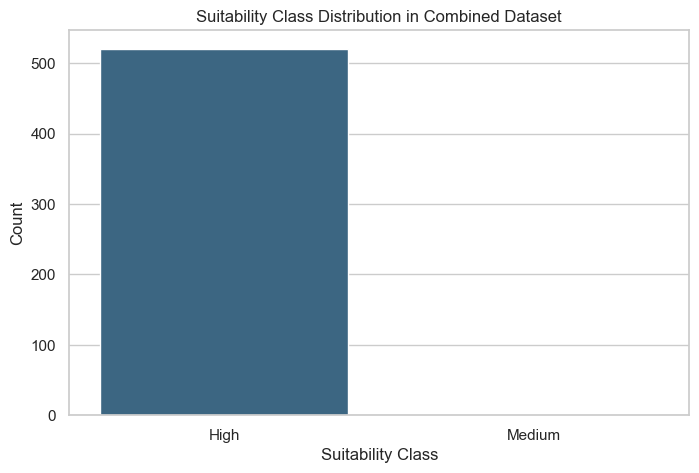

In [13]:
target_counts = df["suitability"].value_counts(dropna=False).rename_axis("suitability").reset_index(name="count")
display(target_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="suitability", order=df["suitability"].value_counts().index, palette="viridis")
plt.title("Suitability Class Distribution in Combined Dataset")
plt.xlabel("Suitability Class")
plt.ylabel("Count")
plt.show()

## 3. Dataset Processing

Steps performed here:

- remove identifier and metadata columns from the feature matrix
- handle missing values
- encode the suitability class labels
- standardize numeric features
- save the processed dataset

In [14]:
exclude_cols = [
    "place_id",
    "name",
    "lat",
    "lng",
    "type",
    "source",
    "suitability",
    "rating",
    "review_count",
    "price_level",
]

feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()
y = df["suitability"].copy()

print("Feature columns used for training:")
for col in feature_cols:
    print(" -", col)

missing_summary = X.isna().sum()
print("\nTotal missing feature values:", int(missing_summary.sum()))
display(missing_summary[missing_summary > 0].to_frame("missing_count"))

if missing_summary.sum() > 0:
    X = X.fillna(X.mean(numeric_only=True))

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

preprocessed_df = X_scaled_df.copy()
preprocessed_df["suitability"] = y_encoded
preprocessed_df.to_csv(PREPROCESSED_DATASET, index=False)

print("\nEncoded classes:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("Preprocessed dataset saved to:", PREPROCESSED_DATASET)
display(preprocessed_df.head())

Feature columns used for training:
 - is_operational
 - competitors_within_500m
 - competitors_within_200m
 - competitors_min_distance
 - competitors_avg_distance
 - roads_within_500m
 - roads_avg_distance
 - schools_within_500m
 - schools_within_200m
 - schools_min_distance
 - hospitals_within_500m
 - hospitals_min_distance
 - bus_stops_within_500m
 - bus_stops_min_distance
 - population_density_proxy
 - accessibility_score
 - foot_traffic_score
 - competition_pressure

Total missing feature values: 9333


,missing_count
competitors_within_500m,549
competitors_within_200m,549
competitors_min_distance,549
competitors_avg_distance,549
roads_within_500m,549
roads_avg_distance,549
schools_within_500m,549
schools_within_200m,549
schools_min_distance,549
hospitals_within_500m,549



Encoded classes: {'High': np.int64(0), 'Medium': np.int64(1), nan: np.int64(2)}
Preprocessed dataset saved to: D:\vscode\MP2\cafelocate\data\preprocessed_combined_dataset.csv


,is_operational,competitors_within_500m,competitors_within_200m,competitors_min_distance,competitors_avg_distance,roads_within_500m,roads_avg_distance,schools_within_500m,schools_within_200m,schools_min_distance,hospitals_within_500m,hospitals_min_distance,bus_stops_within_500m,bus_stops_min_distance,population_density_proxy,accessibility_score,foot_traffic_score,competition_pressure,suitability
0,0.0,0.0,-1.976450e-16,0.0,1.174309e-15,0.0,0.0,0.0,0.0,0.0,3.067924e-16,3.072779e-16,0.0,0.0,0.0,0.0,0.0,-9.634531e-16,2
1,0.0,0.0,-1.976450e-16,0.0,1.174309e-15,0.0,0.0,0.0,0.0,0.0,3.067924e-16,3.072779e-16,0.0,0.0,0.0,0.0,0.0,-9.634531e-16,2
2,0.0,0.0,-1.976450e-16,0.0,1.174309e-15,0.0,0.0,0.0,0.0,0.0,3.067924e-16,3.072779e-16,0.0,0.0,0.0,0.0,0.0,-9.634531e-16,2
3,0.0,0.0,-1.976450e-16,0.0,1.174309e-15,0.0,0.0,0.0,0.0,0.0,3.067924e-16,3.072779e-16,0.0,0.0,0.0,0.0,0.0,-9.634531e-16,2
4,0.0,0.0,-1.976450e-16,0.0,1.174309e-15,0.0,0.0,0.0,0.0,0.0,3.067924e-16,3.072779e-16,0.0,0.0,0.0,0.0,0.0,-9.634531e-16,2


## 4. Split the Dataset into 80:20 and 85:15

In [15]:
split_configs = {
    "v2_80_20": 0.20,
    "v3_85_15": 0.15,
}

split_data = {}
split_rows = []

for split_name, test_size in split_configs.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled_df,
        y_encoded,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y_encoded,
    )

    split_data[split_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }

    split_rows.append({
        "split_name": split_name,
        "train_ratio": round(1 - test_size, 2),
        "test_ratio": round(test_size, 2),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
    })

split_summary_df = pd.DataFrame(split_rows)
display(split_summary_df)

,split_name,train_ratio,test_ratio,train_samples,test_samples
0,v2_80_20,0.80,0.20,857,215
1,v3_85_15,0.85,0.15,911,161


## 5. Train Random Forest and XGBoost on Each Split

In [1]:
def evaluate_classifier(model_name, model, split_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "split_name": split_name,
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "cv_score": cross_val_score(model, X_train, y_train, cv=5).mean(),
    }

    details = {
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            output_dict=True,
            zero_division=0,
        ),
    }

    return model, metrics, details

comparison_rows = []
detailed_results = {}
trained_models = {}

for split_name, split_values in split_data.items():
    X_train = split_values["X_train"]
    X_test = split_values["X_test"]
    y_train = split_values["y_train"]
    y_test = split_values["y_test"]

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="multi_logloss",
    )

    for model_name, model in [("Random Forest", rf_model), ("XGBoost", xgb_model)]:
        trained_model, metrics, details = evaluate_classifier(
            model_name,
            model,
            split_name,
            X_train,
            X_test,
            y_train,
            y_test,
        )
        comparison_rows.append(metrics)
        detailed_results[(split_name, model_name)] = details
        trained_models[(split_name, model_name)] = trained_model

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["accuracy", "f1_score", "cv_score"], ascending=False
).reset_index(drop=True)

display(comparison_df)

NameError: name 'split_data' is not defined

In [ ]:
comparison_output = MODELS_DIR / "notebook_model_comparison.csv"
comparison_df.to_csv(comparison_output, index=False)
print("Comparison table saved to:", comparison_output)

report_output = MODELS_DIR / "notebook_model_comparison.json"
with open(report_output, "w", encoding="utf-8") as f:
    json.dump(
        {
            "feature_columns": feature_cols,
            "label_mapping": dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))),
            "results": comparison_rows,
        },
        f,
        indent=2,
    )
print("JSON summary saved to:", report_output)

## 6. Tabular Performance Comparison

In [ ]:
metric_columns = ["accuracy", "precision", "recall", "f1_score", "cv_score"]
styled = comparison_df.style.format({col: "{:.4f}" for col in metric_columns})
display(styled)

## 7. Graphical Performance Comparison

In [ ]:
plot_df = comparison_df.copy()
plot_df["label"] = plot_df["split_name"] + " | " + plot_df["model"]

melted_df = plot_df.melt(
    id_vars=["label"],
    value_vars=["accuracy", "precision", "recall", "f1_score", "cv_score"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x="metric", y="score", hue="label", palette="Set2")
plt.title("Model Performance Comparison Across Splits")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Split | Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

ordered_items = [
    ("v2_80_20", "Random Forest"),
    ("v2_80_20", "XGBoost"),
    ("v3_85_15", "Random Forest"),
    ("v3_85_15", "XGBoost"),
]

for ax, key in zip(axes, ordered_items):
    split_name, model_name = key
    cm = detailed_results[key]["confusion_matrix"]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax,
    )
    ax.set_title(f"{split_name} - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest Example)

In [ ]:
best_rf_key = None
for key in [("v3_85_15", "Random Forest"), ("v2_80_20", "Random Forest")]:
    if key in trained_models:
        best_rf_key = key
        break

if best_rf_key is not None:
    rf_model = trained_models[best_rf_key]
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(10))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="crest")
    plt.title(f"Top 10 Feature Importances - {best_rf_key[0]} Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 9. Conclusion for the ML Pipelines

In [ ]:
best_model_row = comparison_df.sort_values(
    by=["accuracy", "f1_score", "cv_score"], ascending=False
).iloc[0]

best_model_name = best_model_row["model"]
best_split_name = best_model_row["split_name"]

conclusion_text = f'''
### Conclusion

- The notebook successfully documented dataset collection, preprocessing, model training, evaluation, and comparison for the combined dataset pipeline.
- Two split strategies were tested: **80:20** and **85:15**.
- Two models were trained on each split: **Random Forest** and **XGBoost**.
- Based on the comparison table, the best-performing setup in this notebook is **{best_model_name}** on the **{best_split_name}** split.
- The final choice should consider not only accuracy, but also precision, recall, F1-score, and cross-validation consistency.
- This pipeline provides a clear experimental basis for reporting which split and model combination works best for the processed combined cafe-location dataset.
'''

display(Markdown(conclusion_text))